# IMU data analysis --- Run012

In [13]:
!pip install allantools -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats
import allantools
import warnings
warnings.filterwarnings('ignore')

# ────────────────────────────────────────────────────────────
# Global plot style
# ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'lines.linewidth': 0.8,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
COLORS = {'x': '#E74C3C', 'y': '#2ECC71', 'z': '#3498DB', 'mag': '#9B59B6'}
SENSOR_UNITS = {'gyro': 'rad/s', 'accel': 'm/s²', 'mag': 'µT'}

print("=" * 60)
print("  BNO085 IMU Static-State Error Analysis")
print("=" * 60)

  BNO085 IMU Static-State Error Analysis


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# ============================================================
# Module 1: Data Loading & Automatic Column Detection
# ============================================================
print("\n[1/8] Loading data...")

DATA_ROOT = "/content/drive/MyDrive/capstone_data/UNIT_0001_RUN_012"

def load_sensor(path, sensor_name):
    """
    Read a sensor CSV file and auto-detect the timestamp column
    and the x/y/z data columns.
    Returns a DataFrame with unified columns: [timestamp_ms, x, y, z, time_s]
    """
    df = pd.read_csv(path)
    print(f"\n  [{sensor_name}] Raw columns : {list(df.columns)}")
    print(f"  [{sensor_name}] Rows: {len(df):,}  |  Columns: {df.shape[1]}")

    # -- Auto-detect timestamp column --
    time_col = None
    for c in df.columns:
        if any(k in c.lower() for k in ['time', 'ts', 'stamp', 'ms', 't']):
            time_col = c
            break
    if time_col is None:
        time_col = df.columns[0]   # fallback: first column
    print(f"  [{sensor_name}] Timestamp column detected: '{time_col}'")

    # -- Auto-detect x/y/z columns --
    xyz_cols = []
    for c in df.columns:
        cl = c.lower()
        if cl in ['x', 'y', 'z'] or cl.endswith('_x') or cl.endswith('_y') or cl.endswith('_z'):
            xyz_cols.append(c)
    if len(xyz_cols) < 3:
        # fallback: take the first three non-timestamp columns
        xyz_cols = [c for c in df.columns if c != time_col][:3]
    print(f"  [{sensor_name}] Data columns detected: {xyz_cols}")

    # -- Standardise column names --
    df = df[[time_col] + xyz_cols].copy()
    df.columns = ['timestamp_ms', 'x', 'y', 'z']

    # -- Convert to numeric --
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # -- Normalise time to seconds (starting from 0) --
    df['time_s'] = (df['timestamp_ms'] - df['timestamp_ms'].iloc[0]) / 1000.0

    return df

try:
    df_accel = load_sensor(f"{DATA_ROOT}/accelerometer.csv", "Accel")
    df_gyro  = load_sensor(f"{DATA_ROOT}/gyroscope.csv",     "Gyro")
    df_mag   = load_sensor(f"{DATA_ROOT}/magnetometer.csv",  "Mag")
    print("\n✅ All three sensor files loaded successfully.")
except FileNotFoundError as e:
    print(f"\n❌ File not found: {e}")
    print("Please make sure Google Drive is mounted and the path is correct.")
    raise



[1/8] Loading data...

  [Accel] Raw columns : ['timestamp_ms', 'x', 'y', 'z']
  [Accel] Rows: 13,499,334  |  Columns: 4
  [Accel] Timestamp column detected: 'timestamp_ms'
  [Accel] Data columns detected: ['x', 'y', 'z']

  [Gyro] Raw columns : ['timestamp_ms', 'x', 'y', 'z']
  [Gyro] Rows: 5,395,802  |  Columns: 4
  [Gyro] Timestamp column detected: 'timestamp_ms'
  [Gyro] Data columns detected: ['x', 'y', 'z']

  [Mag] Raw columns : ['timestamp_ms', 'x', 'y', 'z']
  [Mag] Rows: 5,385,000  |  Columns: 4
  [Mag] Timestamp column detected: 'timestamp_ms'
  [Mag] Data columns detected: ['x', 'y', 'z']

✅ All three sensor files loaded successfully.


In [16]:
# ============================================================
# Module 2: Data Cleaning & Basic Statistics
# ============================================================
print("\n[2/8] Cleaning data...")

def clean_and_report(df, name):
    report = {}

    # Missing values
    missing = df.isnull().sum()
    report['missing'] = missing.to_dict()

    # Duplicate rows
    dup = df.duplicated().sum()
    report['duplicates'] = int(dup)

    # Drop missing and duplicate rows
    before = len(df)
    df = df.dropna().drop_duplicates().reset_index(drop=True)
    after = len(df)
    report['dropped'] = before - after

    # Timestamp monotonicity & sampling stats
    dt = df['timestamp_ms'].diff().dropna()
    report['dt_min_ms']  = float(dt.min())
    report['dt_max_ms']  = float(dt.max())
    report['dt_mean_ms'] = float(dt.mean())
    report['freq_hz']    = round(1000.0 / dt.mean(), 2) if dt.mean() > 0 else None
    report['duration_s'] = float(df['time_s'].iloc[-1])

    print(f"\n  [{name}]")
    print(f"    Valid rows : {after:,}  |  Dropped: {report['dropped']}")
    print(f"    Duration   : {report['duration_s']:.2f} s  |  Estimated freq: {report['freq_hz']} Hz")
    print(f"    dt range   : [{report['dt_min_ms']:.2f}, {report['dt_max_ms']:.2f}] ms  (mean: {report['dt_mean_ms']:.2f} ms)")
    print(f"    Missing    : {report['missing']}")
    if dup > 0:
        print(f"    ⚠️  Duplicate rows: {dup}")

    return df, report

df_accel, rep_accel = clean_and_report(df_accel, "Accel")
df_gyro,  rep_gyro  = clean_and_report(df_gyro,  "Gyro")
df_mag,   rep_mag   = clean_and_report(df_mag,   "Mag")

# Descriptive statistics
print("\n-- Descriptive Statistics --")
for name, df in [("Accel", df_accel), ("Gyro", df_gyro), ("Mag", df_mag)]:
    print(f"\n  {name}:")
    print(df[['x','y','z']].describe().round(5).to_string(index=True))


[2/8] Cleaning data...

  [Accel]
    Valid rows : 13,499,334  |  Dropped: 0
    Duration   : 54000.00 s  |  Estimated freq: 249.99 Hz
    dt range   : [1.00, 295.00] ms  (mean: 4.00 ms)
    Missing    : {'timestamp_ms': 0, 'x': 0, 'y': 0, 'z': 0, 'time_s': 0}

  [Gyro]
    Valid rows : 5,395,802  |  Dropped: 0
    Duration   : 54000.00 s  |  Estimated freq: 99.92 Hz
    dt range   : [1.00, 310.00] ms  (mean: 10.01 ms)
    Missing    : {'timestamp_ms': 0, 'x': 0, 'y': 0, 'z': 0, 'time_s': 0}

  [Mag]
    Valid rows : 5,385,000  |  Dropped: 0
    Duration   : 54000.00 s  |  Estimated freq: 99.72 Hz
    dt range   : [1.00, 300.00] ms  (mean: 10.03 ms)
    Missing    : {'timestamp_ms': 0, 'x': 0, 'y': 0, 'z': 0, 'time_s': 0}

-- Descriptive Statistics --

  Accel:
                  x             y             z
count  1.349933e+07  1.349933e+07  1.349933e+07
mean   3.594500e-01 -2.852000e-01  9.753520e+00
std    2.103600e-01  3.521100e-01  4.270500e-01
min   -1.279805e+02 -1.278281e+02 -


[3/8] Gyro error analysis (GT = 0)...

  Gyro error statistics (rad/s):
    Axis         Bias          Std          RMS    Peak-Peak
       x     0.008333     0.115987     0.116286   127.998047
       y    -0.009304     0.158646     0.158919   127.982422
       z    -0.006300     0.141339     0.141480   127.998047
  Plot downsampling: Gyro 50,429 pts / Accel 50,184 pts  (statistics use full dataset)


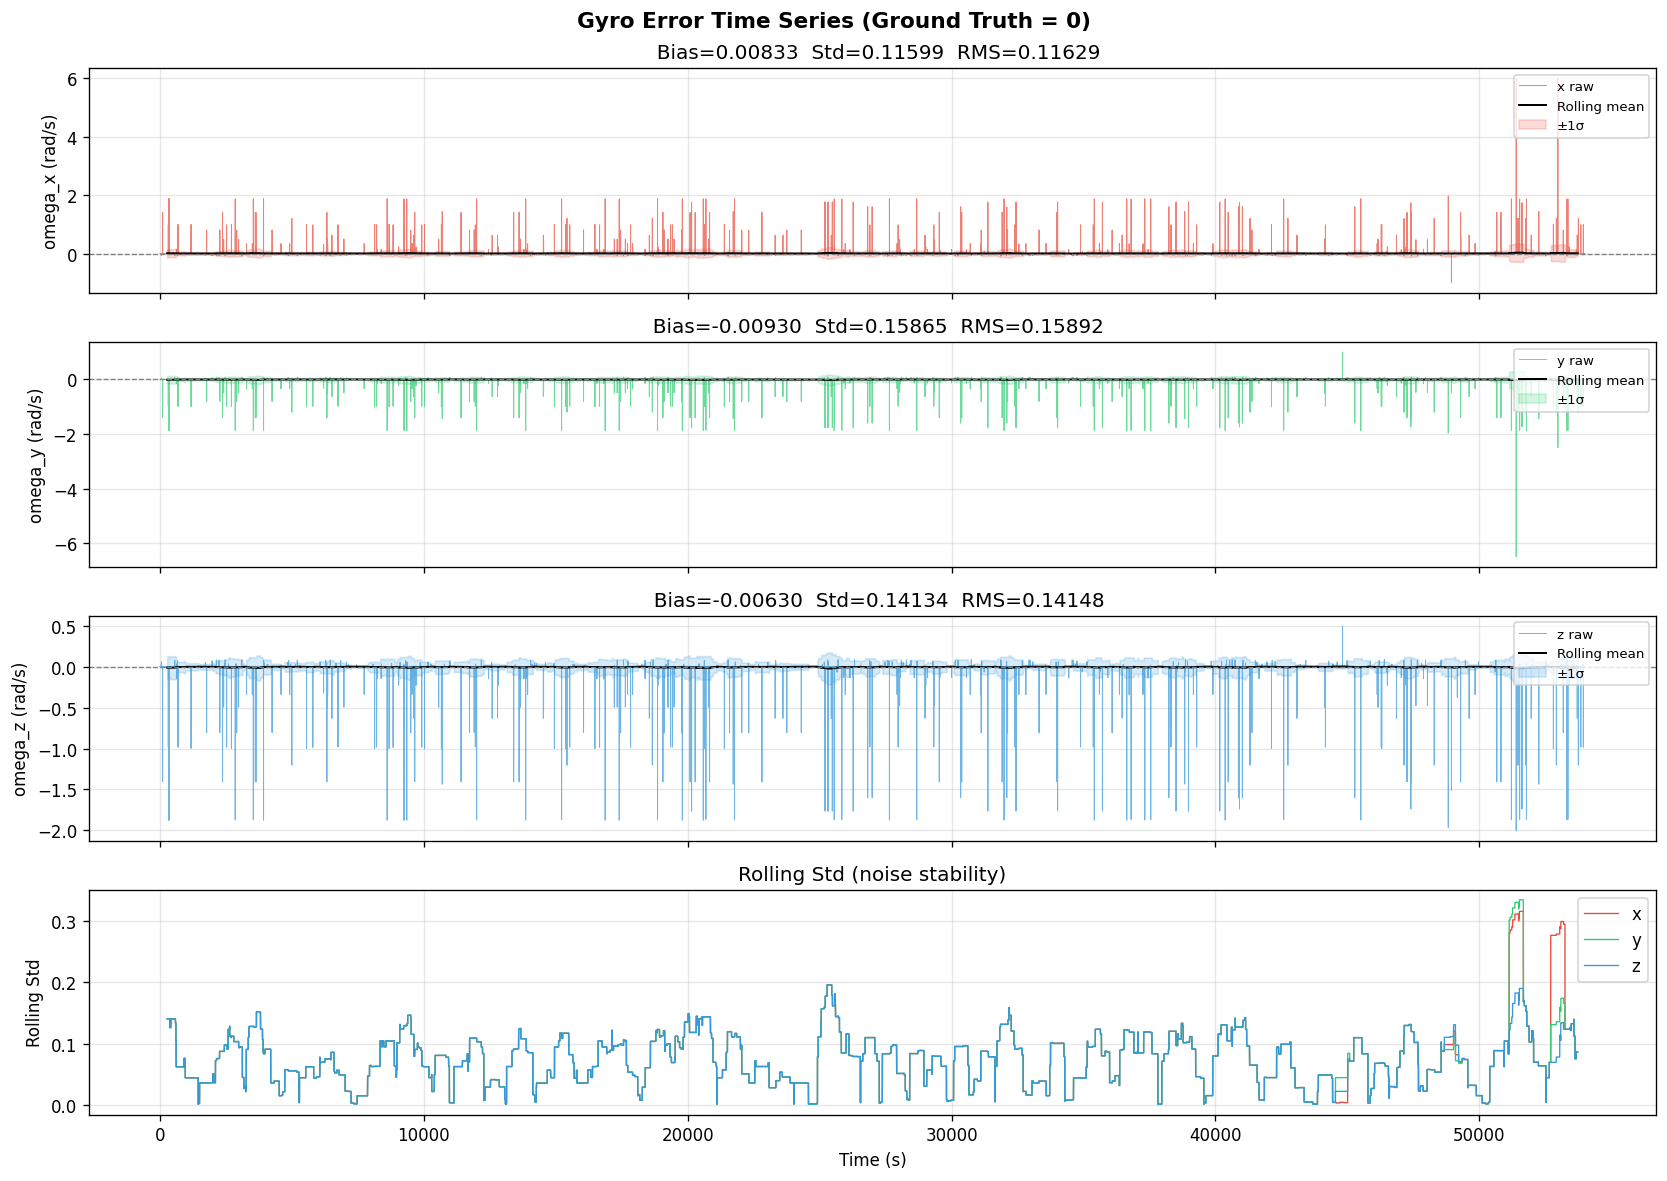

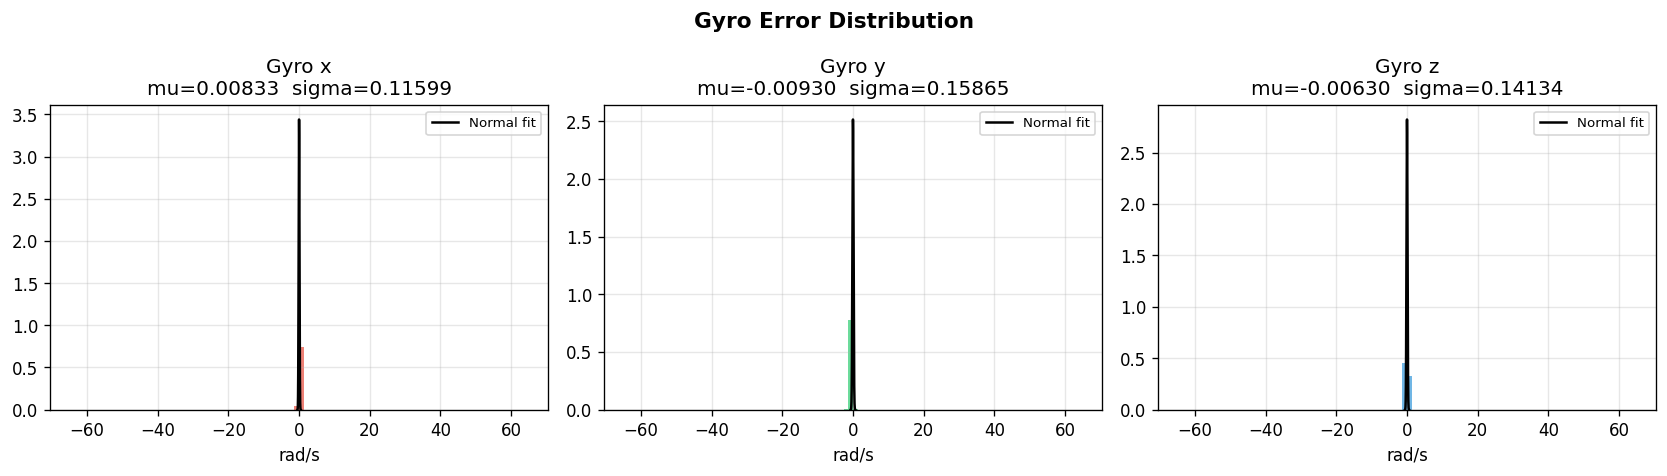

In [17]:
# ============================================================
# Module 3: Gyro Error Analysis (Ground Truth = 0)
# ============================================================
print("\n[3/8] Gyro error analysis (GT = 0)...")

def compute_error_stats(df, axes=['x','y','z'], gt=0.0):
    """Compute bias, std, RMS, peak-to-peak, kurtosis and skewness."""
    stats_dict = {}
    for ax in axes:
        err = df[ax] - gt
        stats_dict[ax] = {
            'bias':     float(err.mean()),
            'std':      float(err.std()),
            'rms':      float(np.sqrt((err**2).mean())),
            'min':      float(err.min()),
            'max':      float(err.max()),
            'p2p':      float(err.max() - err.min()),
            'kurtosis': float(err.kurtosis()),
            'skewness': float(err.skew()),
        }
    return stats_dict

gyro_stats = compute_error_stats(df_gyro)

print("\n  Gyro error statistics (rad/s):")
print(f"  {'Axis':>6} {'Bias':>12} {'Std':>12} {'RMS':>12} {'Peak-Peak':>12}")
for ax in ['x','y','z']:
    s = gyro_stats[ax]
    print(f"  {ax:>6} {s['bias']:>12.6f} {s['std']:>12.6f} {s['rms']:>12.6f} {s['p2p']:>12.6f}")

# -- Plot downsampling helper --
# Statistics always use the full dataset; plots use at most PLOT_N points.
PLOT_N = 50_000

def plot_sample(df, n=PLOT_N):
    """Evenly subsample df to at most n rows for plotting."""
    if len(df) <= n:
        return df
    return df.iloc[::len(df)//n].reset_index(drop=True)

df_gyro_plot  = plot_sample(df_gyro)
df_accel_plot = plot_sample(df_accel)
print(f"  Plot downsampling: Gyro {len(df_gyro_plot):,} pts / "
      f"Accel {len(df_accel_plot):,} pts  (statistics use full dataset)")

# -- Figure 3-1: Gyro time series + Rolling Std --
fig, axes_p = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Gyro Error Time Series (Ground Truth = 0)", fontsize=13, fontweight='bold')
win = max(50, len(df_gyro_plot) // 100)

for i, ax_name in enumerate(['x', 'y', 'z']):
    axes_p[i].plot(df_gyro_plot['time_s'], df_gyro_plot[ax_name],
                   color=COLORS[ax_name], alpha=0.7, lw=0.6, label=f'{ax_name} raw')
    roll_mean = df_gyro_plot[ax_name].rolling(win, center=True).mean()
    roll_std  = df_gyro_plot[ax_name].rolling(win, center=True).std()
    axes_p[i].plot(df_gyro_plot['time_s'], roll_mean, color='k', lw=1.2, label='Rolling mean')
    axes_p[i].fill_between(df_gyro_plot['time_s'],
                            roll_mean - roll_std,
                            roll_mean + roll_std,
                            alpha=0.2, color=COLORS[ax_name], label='±1σ')
    axes_p[i].axhline(0, color='gray', ls='--', lw=0.8)
    axes_p[i].set_ylabel(f'omega_{ax_name} (rad/s)')
    axes_p[i].legend(loc='upper right', fontsize=8)
    axes_p[i].set_title(
        f'  Bias={gyro_stats[ax_name]["bias"]:.5f}  '
        f'Std={gyro_stats[ax_name]["std"]:.5f}  '
        f'RMS={gyro_stats[ax_name]["rms"]:.5f}')

# Overlay rolling std for all three axes
for ax_name in ['x', 'y', 'z']:
    rs = df_gyro_plot[ax_name].rolling(win, center=True).std()
    axes_p[3].plot(df_gyro_plot['time_s'], rs, color=COLORS[ax_name], lw=0.8, label=ax_name)
axes_p[3].set_ylabel('Rolling Std')
axes_p[3].set_xlabel('Time (s)')
axes_p[3].legend()
axes_p[3].set_title('Rolling Std (noise stability)')

plt.tight_layout()
plt.savefig("gyro_timeseries.png", bbox_inches='tight')
plt.show()

# -- Figure 3-2: Gyro error distribution --
fig, axes_p = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Gyro Error Distribution", fontsize=13, fontweight='bold')
for i, ax_name in enumerate(['x', 'y', 'z']):
    data = df_gyro[ax_name]
    axes_p[i].hist(data, bins=100, color=COLORS[ax_name], alpha=0.7, density=True)
    mu, sigma = data.mean(), data.std()
    x_range = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
    axes_p[i].plot(x_range, stats.norm.pdf(x_range, mu, sigma),
                   'k-', lw=1.5, label='Normal fit')
    axes_p[i].set_title(f'Gyro {ax_name}\nmu={mu:.5f}  sigma={sigma:.5f}')
    axes_p[i].set_xlabel('rad/s')
    axes_p[i].legend(fontsize=8)
plt.tight_layout()
plt.savefig("gyro_histogram.png", bbox_inches='tight')
plt.show()



[4/8] Accel gravity analysis...

  Accel mean and std per axis (m/s²):
        Axis         Mean          Std
           x      0.35945      0.21036
           y     -0.28520      0.35211
           z      9.75352      0.42705
   magnitude      9.76763      0.53459

  ||a|| vs 9.81 m/s²  Bias=-0.04237  Std=0.53459


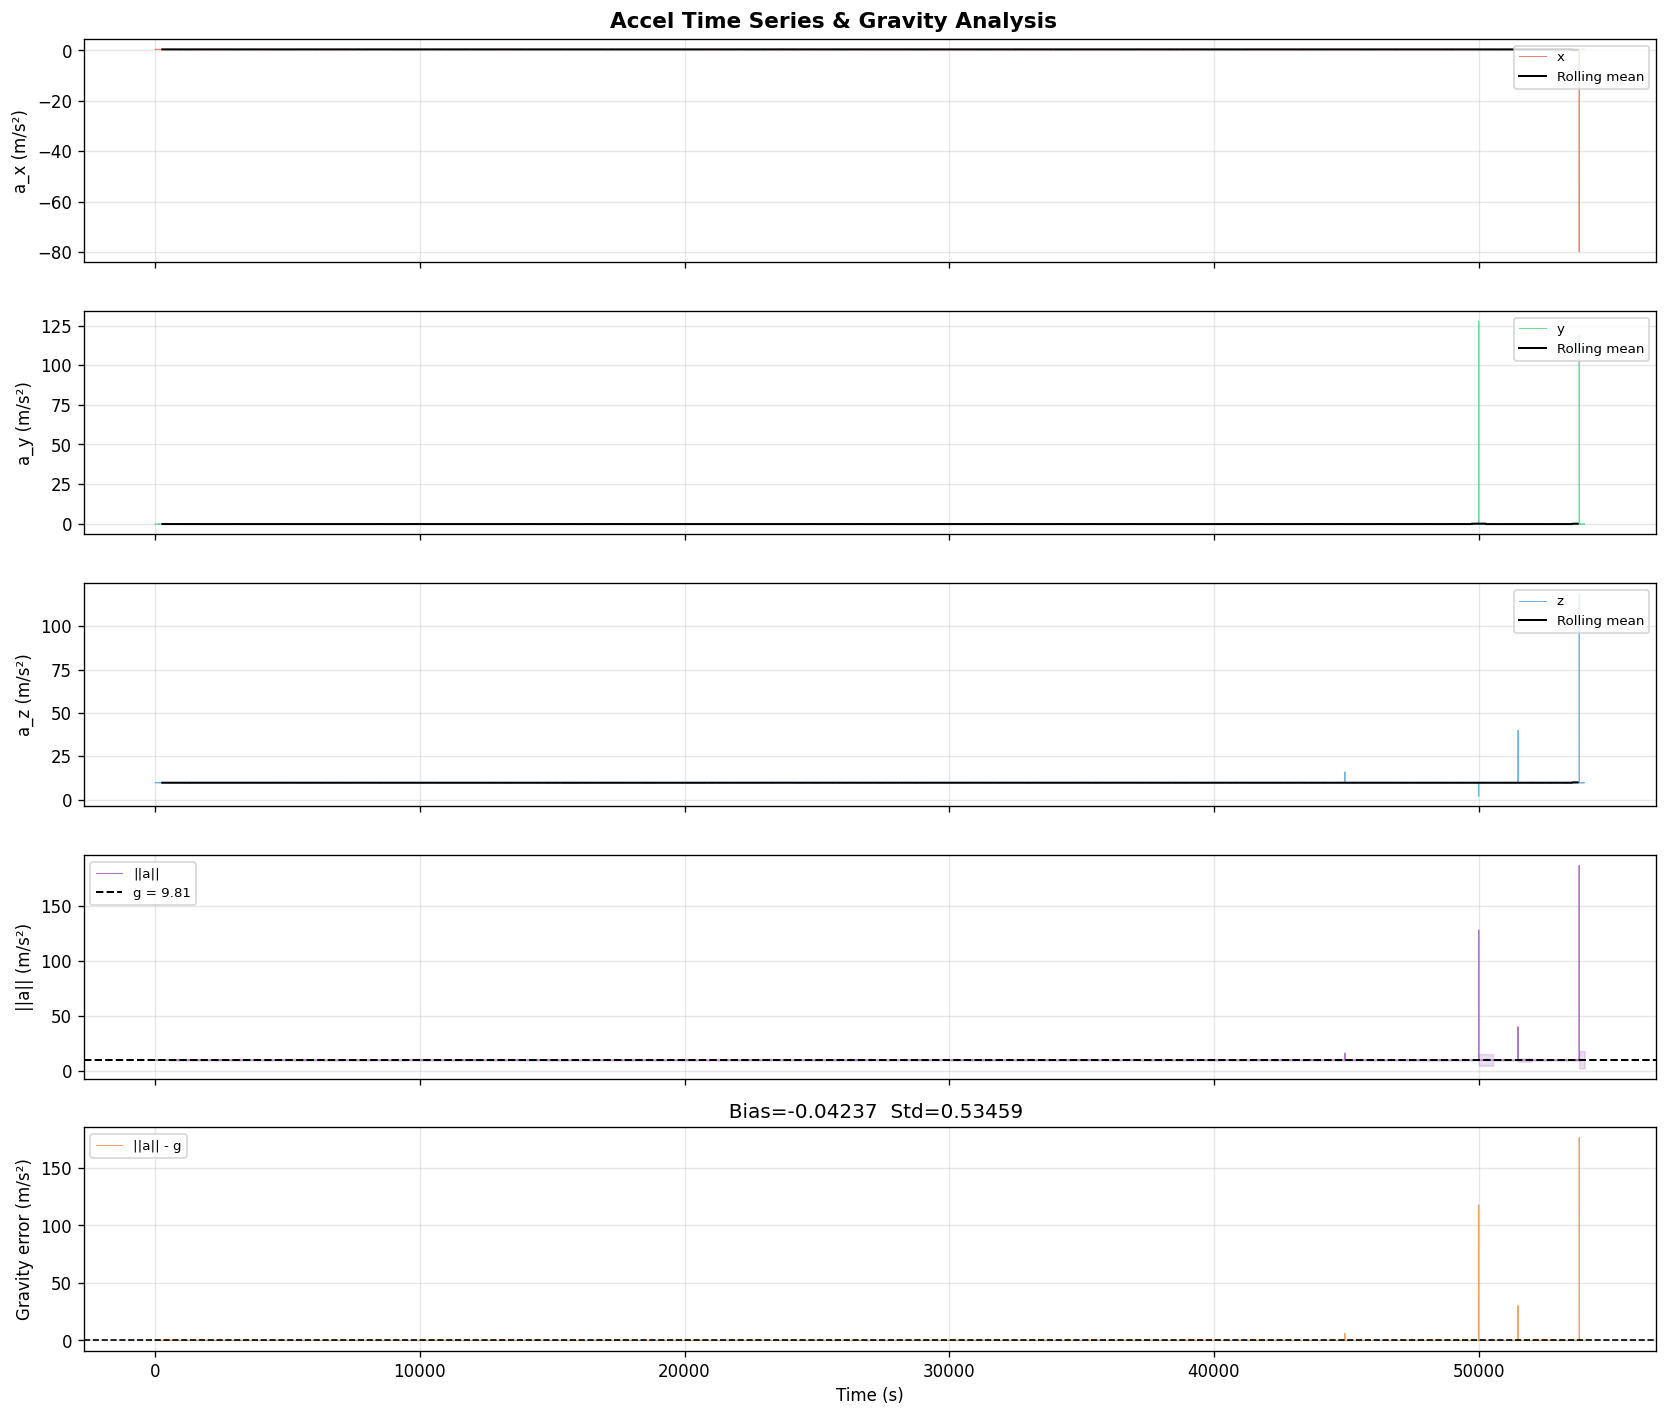

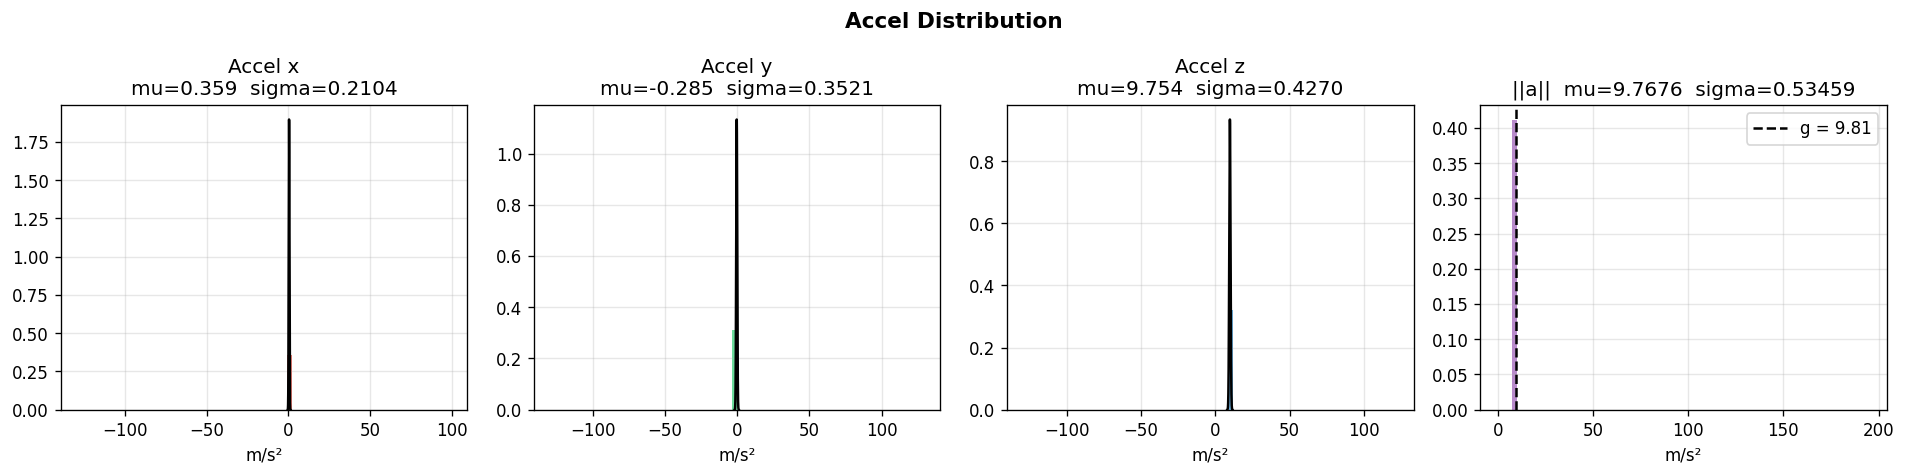

In [18]:
# ============================================================
# Module 4: Accel Gravity Analysis
# ============================================================
print("\n[4/8] Accel gravity analysis...")

GRAVITY = 9.81  # m/s²  -- change to 1.0 if your data is in units of g

df_accel['magnitude']  = np.sqrt(df_accel['x']**2 + df_accel['y']**2 + df_accel['z']**2)
df_accel['grav_error'] = df_accel['magnitude'] - GRAVITY
df_accel_plot = plot_sample(df_accel)

accel_stats = {}
for ax in ['x', 'y', 'z', 'magnitude']:
    col = df_accel[ax]
    accel_stats[ax] = {
        'mean': float(col.mean()),
        'std':  float(col.std()),
        'rms':  float(np.sqrt((col**2).mean())),
    }
accel_stats['grav_error'] = {
    'bias': float(df_accel['grav_error'].mean()),
    'std':  float(df_accel['grav_error'].std()),
    'rms':  float(np.sqrt((df_accel['grav_error']**2).mean())),
}

print("\n  Accel mean and std per axis (m/s²):")
print(f"  {'Axis':>10} {'Mean':>12} {'Std':>12}")
for ax in ['x', 'y', 'z', 'magnitude']:
    s = accel_stats[ax]
    print(f"  {ax:>10} {s['mean']:>12.5f} {s['std']:>12.5f}")
print(f"\n  ||a|| vs {GRAVITY} m/s²  "
      f"Bias={accel_stats['grav_error']['bias']:.5f}  "
      f"Std={accel_stats['grav_error']['std']:.5f}")

# -- Figure 4-1: Accel time series + magnitude --
fig, axes_p = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
fig.suptitle("Accel Time Series & Gravity Analysis", fontsize=13, fontweight='bold')
win = max(50, len(df_accel_plot) // 100)

for i, ax_name in enumerate(['x', 'y', 'z']):
    axes_p[i].plot(df_accel_plot['time_s'], df_accel_plot[ax_name],
                   color=COLORS[ax_name], alpha=0.7, lw=0.6, label=ax_name)
    axes_p[i].plot(df_accel_plot['time_s'],
                   df_accel_plot[ax_name].rolling(win, center=True).mean(),
                   color='k', lw=1.2, label='Rolling mean')
    axes_p[i].set_ylabel(f'a_{ax_name} (m/s²)')
    axes_p[i].legend(loc='upper right', fontsize=8)

# Magnitude subplot
mag_roll_mean = df_accel_plot['magnitude'].rolling(win).mean()
mag_roll_std  = df_accel_plot['magnitude'].rolling(win).std()
axes_p[3].plot(df_accel_plot['time_s'], df_accel_plot['magnitude'],
               color=COLORS['mag'], alpha=0.8, lw=0.7, label='||a||')
axes_p[3].axhline(GRAVITY, color='k', ls='--', lw=1.2, label=f'g = {GRAVITY}')
axes_p[3].fill_between(df_accel_plot['time_s'],
                        mag_roll_mean - mag_roll_std,
                        mag_roll_mean + mag_roll_std,
                        alpha=0.2, color=COLORS['mag'])
axes_p[3].set_ylabel('||a|| (m/s²)')
axes_p[3].legend(fontsize=8)

# Gravity error subplot
axes_p[4].plot(df_accel_plot['time_s'], df_accel_plot['grav_error'],
               color='#E67E22', alpha=0.7, lw=0.6, label='||a|| - g')
axes_p[4].axhline(0, color='k', ls='--', lw=1)
axes_p[4].set_ylabel('Gravity error (m/s²)')
axes_p[4].set_xlabel('Time (s)')
axes_p[4].legend(fontsize=8)
axes_p[4].set_title(
    f'  Bias={accel_stats["grav_error"]["bias"]:.5f}  '
    f'Std={accel_stats["grav_error"]["std"]:.5f}')

plt.tight_layout()
plt.savefig("accel_timeseries.png", bbox_inches='tight')
plt.show()

# -- Figure 4-2: Accel distribution + magnitude distribution --
fig, axes_p = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Accel Distribution", fontsize=13, fontweight='bold')
for i, ax_name in enumerate(['x', 'y', 'z']):
    data = df_accel[ax_name]
    axes_p[i].hist(data, bins=80, color=COLORS[ax_name], alpha=0.7, density=True)
    mu, sigma = data.mean(), data.std()
    xr = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
    axes_p[i].plot(xr, stats.norm.pdf(xr, mu, sigma), 'k-', lw=1.5)
    axes_p[i].set_title(f'Accel {ax_name}\nmu={mu:.3f}  sigma={sigma:.4f}')
    axes_p[i].set_xlabel('m/s²')

data = df_accel['magnitude']
axes_p[3].hist(data, bins=80, color=COLORS['mag'], alpha=0.7, density=True)
axes_p[3].axvline(GRAVITY, color='k', ls='--', lw=1.5, label='g = 9.81')
axes_p[3].set_title(f'||a||  mu={data.mean():.4f}  sigma={data.std():.5f}')
axes_p[3].set_xlabel('m/s²')
axes_p[3].legend()
plt.tight_layout()
plt.savefig("accel_histogram.png", bbox_inches='tight')
plt.show()


[5/8] Magnetometer stability analysis...

  Mag statistics (uT):
        Axis         Mean          Std        Range      CV%
           x       7.1362       3.1462    3584.7500   44.088%
           y      -9.1238       4.7554    4080.2500   52.121%
           z       7.4601       6.2816    4094.3750   84.203%
   magnitude      13.8537       8.3587    3171.2692   60.336%
  Plotting with 50,328 pts (statistics use full 5,385,000 pts)


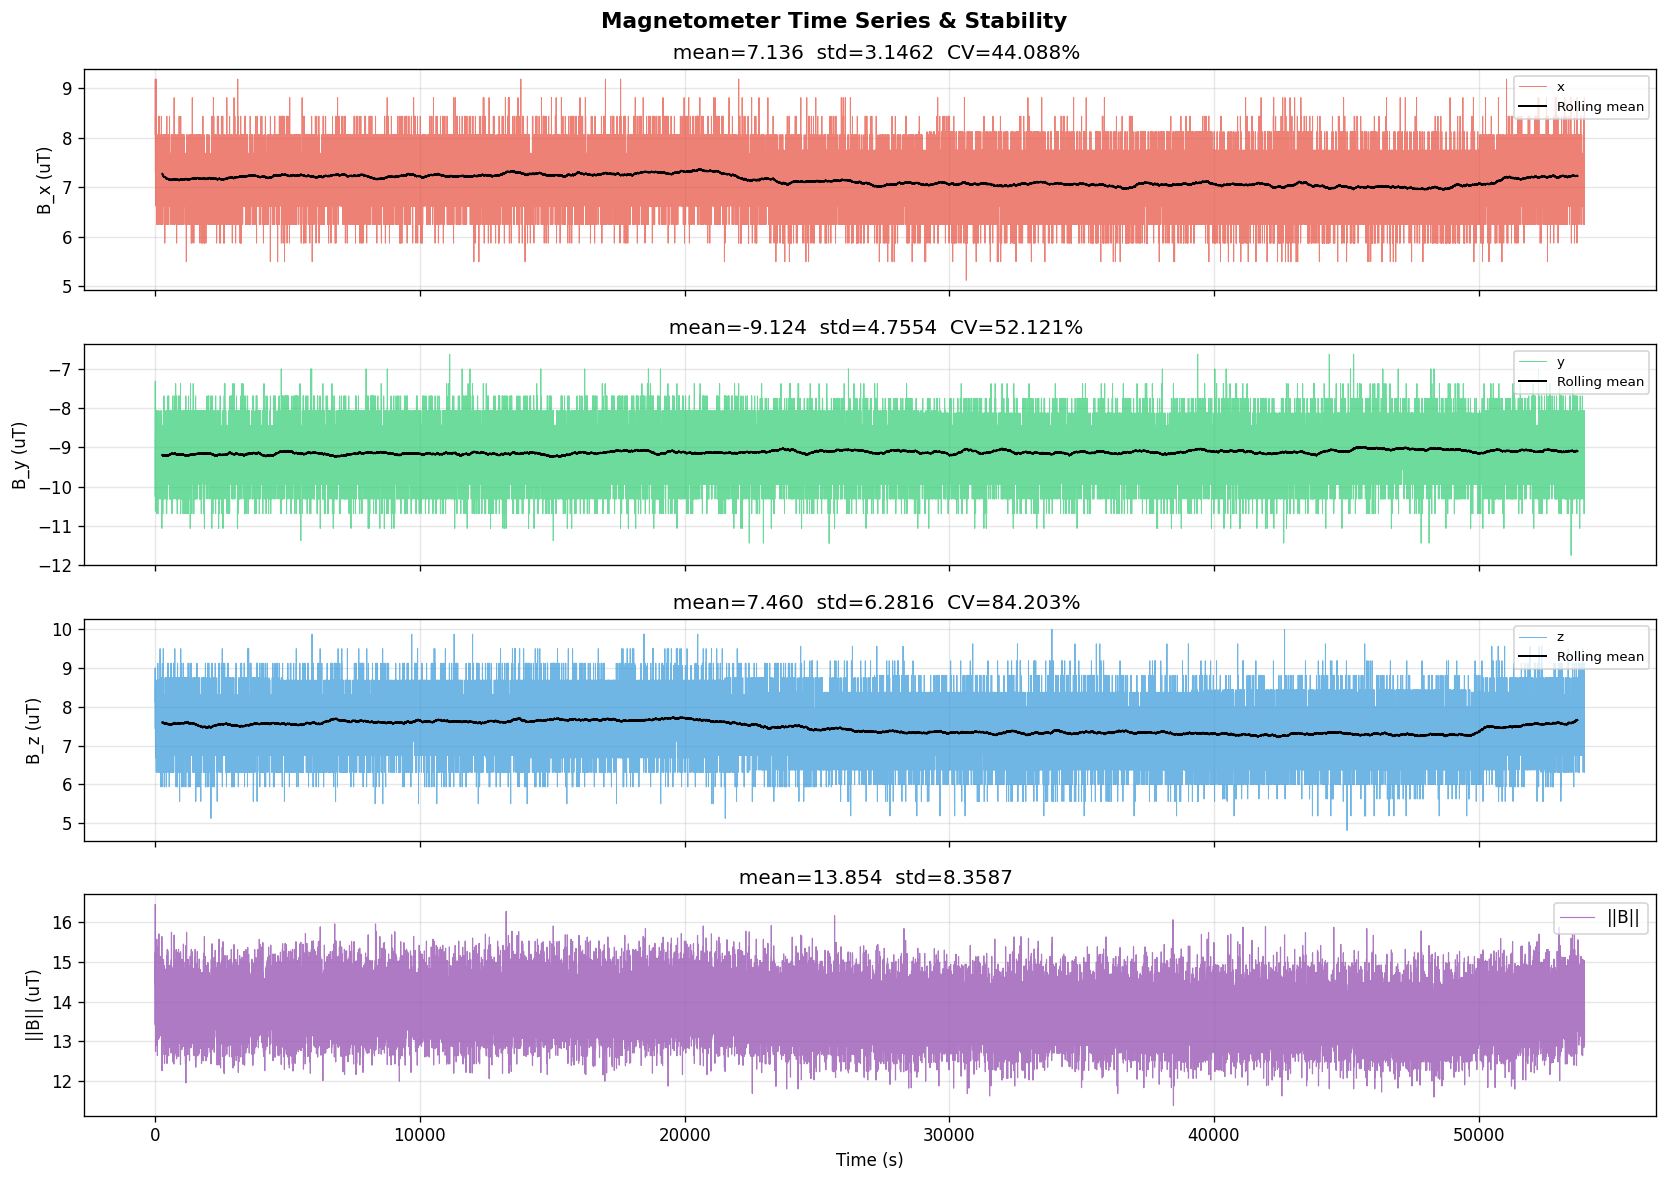

In [19]:
# ============================================================
# Module 5: Magnetometer Stability Analysis
# ============================================================
print("\n[5/8] Magnetometer stability analysis...")

df_mag['magnitude'] = np.sqrt(df_mag['x']**2 + df_mag['y']**2 + df_mag['z']**2)

mag_stats = {}
for ax in ['x', 'y', 'z', 'magnitude']:
    col = df_mag[ax]
    mag_stats[ax] = {
        'mean':  float(col.mean()),
        'std':   float(col.std()),
        'range': float(col.max() - col.min()),
        'cv':    float(col.std() / abs(col.mean()) * 100) if col.mean() != 0 else np.nan,
    }

print("\n  Mag statistics (uT):")
print(f"  {'Axis':>10} {'Mean':>12} {'Std':>12} {'Range':>12} {'CV%':>8}")
for ax in ['x', 'y', 'z', 'magnitude']:
    s = mag_stats[ax]
    print(f"  {ax:>10} {s['mean']:>12.4f} {s['std']:>12.4f} {s['range']:>12.4f} {s['cv']:>8.3f}%")

# Plot downsampling (statistics always use full dataset)
df_mag_plot = plot_sample(df_mag)
print(f"  Plotting with {len(df_mag_plot):,} pts "
      f"(statistics use full {len(df_mag):,} pts)")

# -- Figure 5-1: Mag time series --
fig, axes_p = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Magnetometer Time Series & Stability", fontsize=13, fontweight='bold')
win = max(30, len(df_mag_plot) // 100)

for i, ax_name in enumerate(['x', 'y', 'z']):
    axes_p[i].plot(df_mag_plot['time_s'], df_mag_plot[ax_name],
                   color=COLORS[ax_name], alpha=0.7, lw=0.6, label=ax_name)
    axes_p[i].plot(df_mag_plot['time_s'],
                   df_mag_plot[ax_name].rolling(win, center=True).mean(),
                   color='k', lw=1.2, label='Rolling mean')
    axes_p[i].set_ylabel(f'B_{ax_name} (uT)')
    axes_p[i].legend(loc='upper right', fontsize=8)
    axes_p[i].set_title(
        f'  mean={mag_stats[ax_name]["mean"]:.3f}  '
        f'std={mag_stats[ax_name]["std"]:.4f}  '
        f'CV={mag_stats[ax_name]["cv"]:.3f}%')

axes_p[3].plot(df_mag_plot['time_s'], df_mag_plot['magnitude'],
               color=COLORS['mag'], alpha=0.8, lw=0.7, label='||B||')
axes_p[3].set_ylabel('||B|| (uT)')
axes_p[3].set_xlabel('Time (s)')
axes_p[3].legend()
axes_p[3].set_title(
    f'  mean={mag_stats["magnitude"]["mean"]:.3f}  '
    f'std={mag_stats["magnitude"]["std"]:.4f}')

plt.tight_layout()
plt.savefig("mag_timeseries.png", bbox_inches='tight')
plt.show()


[6/8] Outlier detection...

  [Gyro] Outlier counts (z-score > 3):
    Axis    Count    Rate%
       x    23297    0.432%
       y    22336    0.414%
       z    23368    0.433%

  [Accel] Outlier counts (z-score > 3):
    Axis    Count    Rate%
       x       90    0.001%
       y      250    0.002%
       z      461    0.003%

  [Mag] Outlier counts (z-score > 3):
    Axis    Count    Rate%
       x       40    0.001%
       y      109    0.002%
       z      147    0.003%


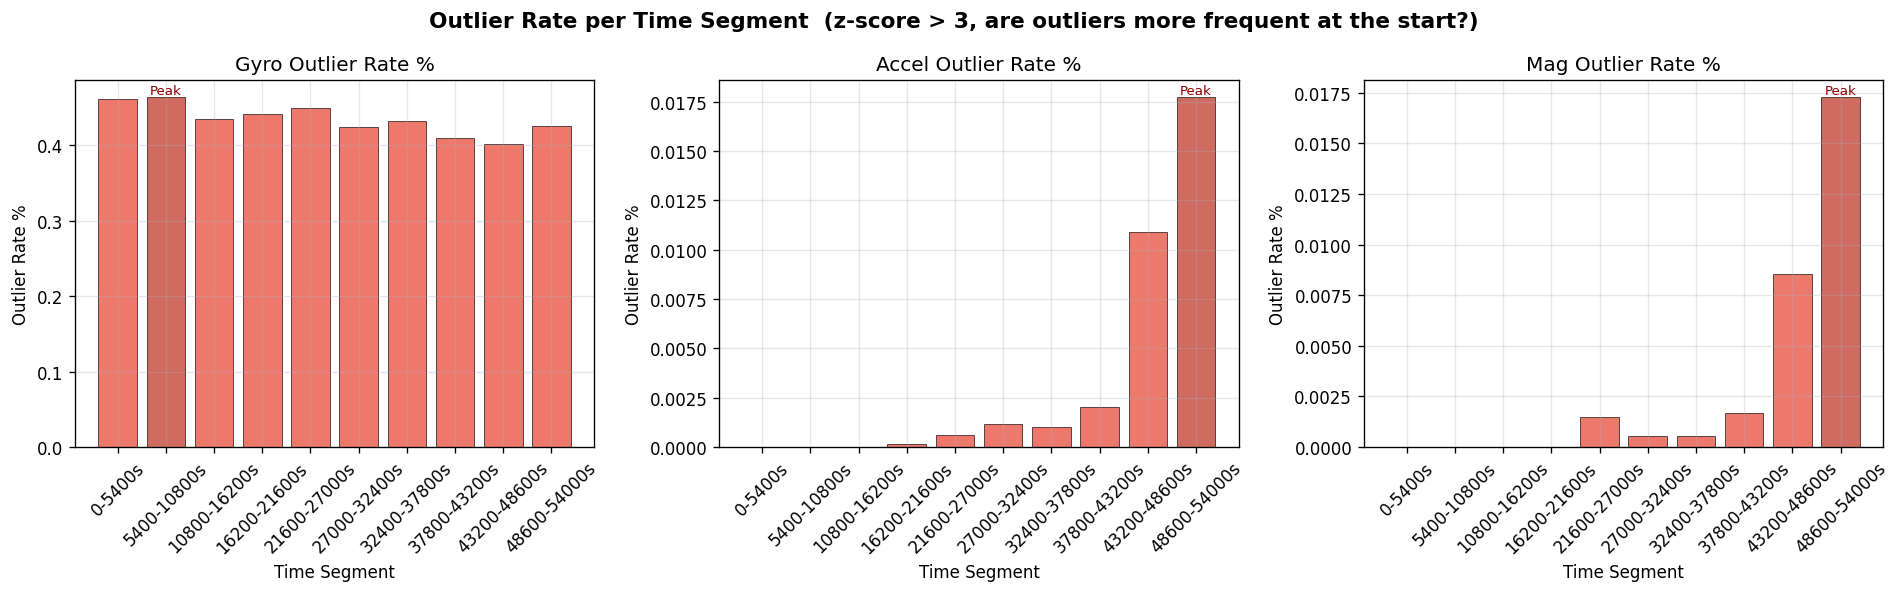

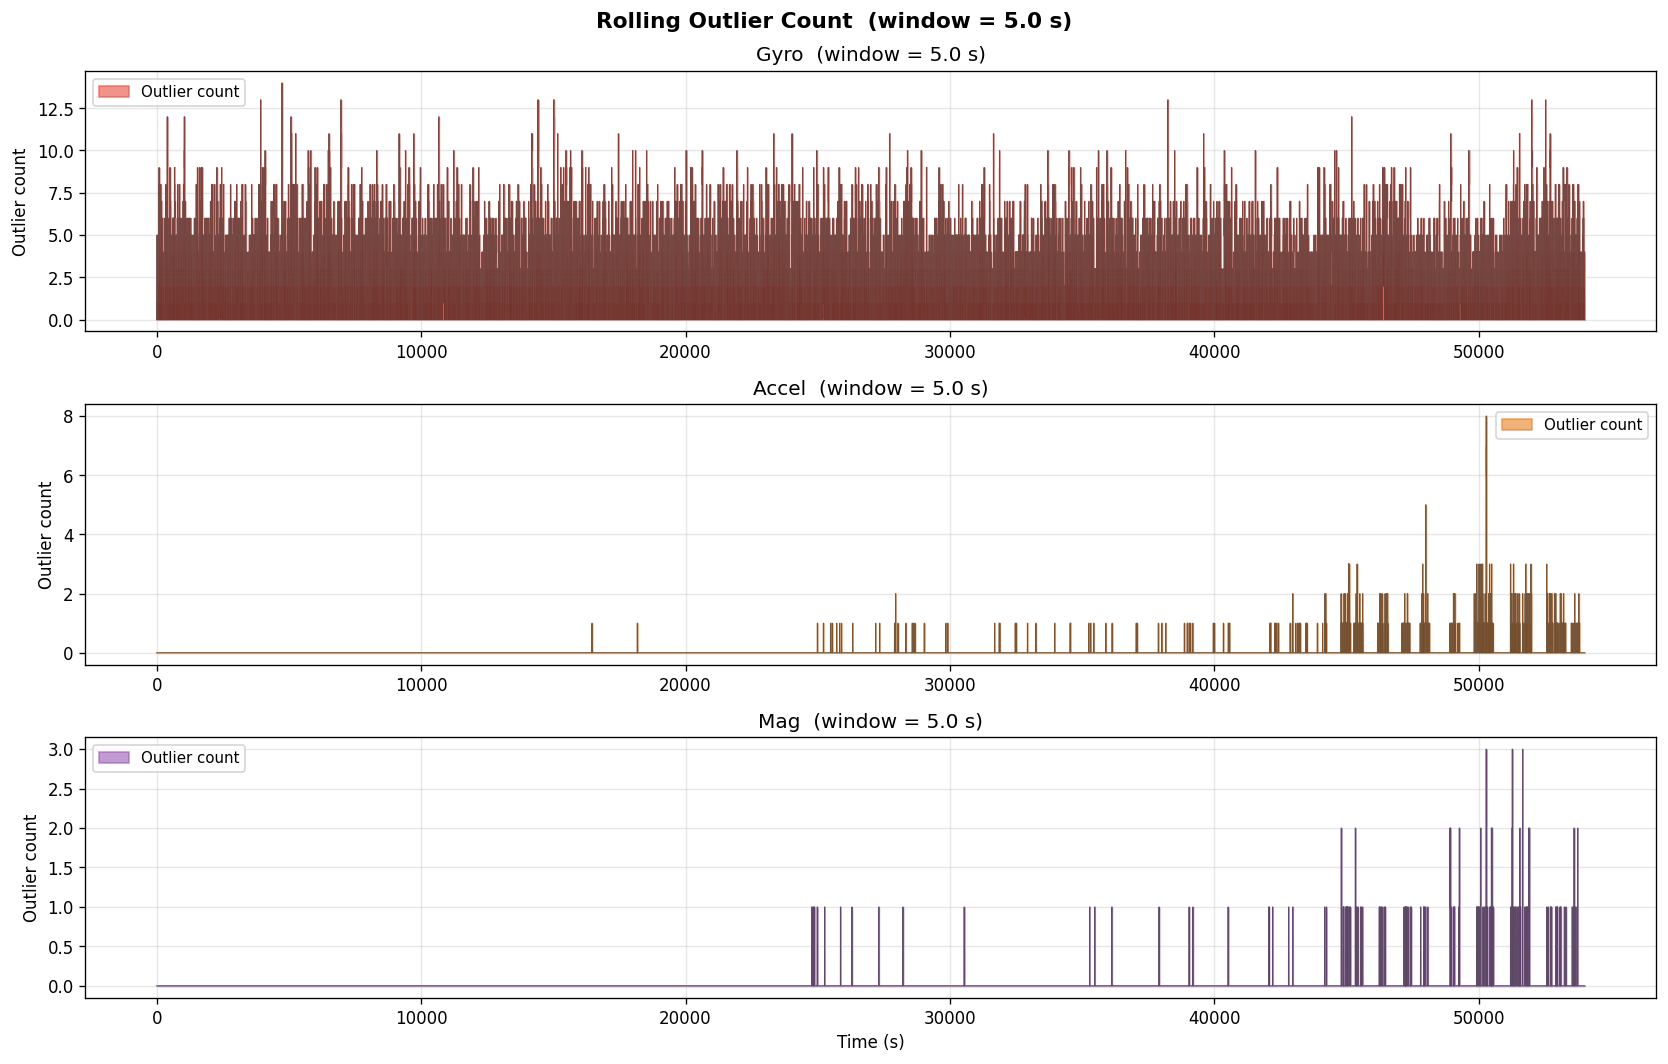


  -- Are outliers more frequent at the start? --
  Gyro: Up  Slightly higher at the start  (0.45% vs 0.42%)
  Accel: OK  No obvious early-start clustering  (0.00% vs 0.01%)
  Mag: OK  No obvious early-start clustering  (0.00% vs 0.01%)


In [20]:
# ============================================================
# Module 6: Outlier Detection & Temporal Distribution
# ============================================================
print("\n[6/8] Outlier detection...")

def detect_outliers(df, axes=['x', 'y', 'z'], threshold=3.0):
    """Return a boolean mask per axis (True = outlier) using z-score."""
    masks = {}
    for ax in axes:
        col  = df[ax]
        z    = np.abs(stats.zscore(col.dropna()))
        idx  = col.dropna().index
        mask = pd.Series(False, index=df.index)
        mask[idx] = z > threshold
        masks[ax] = mask
    return masks

def analyze_outlier_timing(df, masks, sensor_name, n_segments=10):
    """
    Analyse whether outliers cluster in the early portion of the recording.
    Returns the tagged DataFrame, segment labels, and outlier rate per segment.
    """
    print(f"\n  [{sensor_name}] Outlier counts (z-score > 3):")
    print(f"  {'Axis':>6} {'Count':>8} {'Rate%':>8}")
    for ax in ['x', 'y', 'z']:
        m   = masks[ax]
        cnt = m.sum()
        pct = cnt / len(df) * 100
        print(f"  {ax:>6} {cnt:>8} {pct:>8.3f}%")

    # Combine: flag a row if any axis is an outlier
    any_outlier      = masks['x'] | masks['y'] | masks['z']
    df               = df.copy()
    df['is_outlier'] = any_outlier

    # Segment-wise outlier rate
    total_dur  = df['time_s'].iloc[-1]
    seg_size   = total_dur / n_segments
    seg_labels, seg_rates = [], []
    for i in range(n_segments):
        t_start = i * seg_size
        t_end   = (i + 1) * seg_size
        seg     = df[(df['time_s'] >= t_start) & (df['time_s'] < t_end)]
        rate    = seg['is_outlier'].mean() * 100 if len(seg) > 0 else 0.0
        seg_labels.append(f"{t_start:.0f}-{t_end:.0f}s")
        seg_rates.append(rate)

    return df, seg_labels, seg_rates

# Run z-score outlier detection for all three sensors
sensors = {
    'Gyro':  (df_gyro,  ['x', 'y', 'z']),
    'Accel': (df_accel, ['x', 'y', 'z']),
    'Mag':   (df_mag,   ['x', 'y', 'z']),
}
outlier_results = {}
for sname, (sdf, axes) in sensors.items():
    masks_z   = detect_outliers(sdf, axes, threshold=3.0)
    df_tagged, seg_labels, seg_rates = analyze_outlier_timing(sdf, masks_z, sname)
    outlier_results[sname] = {
        'masks_z':    masks_z,
        'df_tagged':  df_tagged,
        'seg_labels': seg_labels,
        'seg_rates':  seg_rates,
    }

sensor_items = [('Gyro', df_gyro), ('Accel', df_accel), ('Mag', df_mag)]

# -- Figure 6-1: Outlier rate per time segment --
fig, axes_p = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Outlier Rate per Time Segment  (z-score > 3, are outliers more frequent at the start?)",
             fontsize=13, fontweight='bold')

for i, sname in enumerate(['Gyro', 'Accel', 'Mag']):
    res  = outlier_results[sname]
    bars = axes_p[i].bar(res['seg_labels'], res['seg_rates'],
                          color='#E74C3C', alpha=0.75, edgecolor='k', lw=0.5)
    axes_p[i].set_title(f'{sname} Outlier Rate %')
    axes_p[i].set_xlabel('Time Segment')
    axes_p[i].set_ylabel('Outlier Rate %')
    axes_p[i].tick_params(axis='x', rotation=45)
    # Highlight the segment with the highest rate
    max_idx = np.argmax(res['seg_rates'])
    bars[max_idx].set_color('#C0392B')
    bars[max_idx].set_edgecolor('k')
    axes_p[i].annotate('Peak', xy=(max_idx, res['seg_rates'][max_idx]),
                         ha='center', va='bottom', fontsize=8, color='darkred')

plt.tight_layout()
plt.savefig("outlier_by_segment.png", bbox_inches='tight')
plt.show()

# -- Figure 6-2: Rolling outlier count --
WINDOW_SIZE_S = 5.0  # seconds per rolling window

fig, axes_p = plt.subplots(3, 1, figsize=(14, 9), sharex=False)
fig.suptitle(f"Rolling Outlier Count  (window = {WINDOW_SIZE_S} s)",
             fontsize=13, fontweight='bold')

for i, (sname, sdf) in enumerate(sensor_items):
    masks   = outlier_results[sname]['masks_z']
    any_out = masks['x'] | masks['y'] | masks['z']
    sdf2    = sdf.copy()
    sdf2['is_outlier'] = any_out.astype(int)
    sdf2    = sdf2.sort_values('time_s').reset_index(drop=True)

    # Approximate rolling window size in rows
    freq_hz  = (rep_accel['freq_hz'] if sname == 'Accel'
                else rep_gyro['freq_hz'] if sname == 'Gyro'
                else rep_mag['freq_hz'])
    win_rows    = max(10, int(WINDOW_SIZE_S * freq_hz)) if freq_hz and freq_hz > 0 else 100
    rolling_cnt = sdf2['is_outlier'].rolling(win_rows, center=True).sum()

    axes_p[i].fill_between(sdf2['time_s'], rolling_cnt,
                            alpha=0.6,
                            color=['#E74C3C', '#E67E22', '#9B59B6'][i],
                            label='Outlier count')
    axes_p[i].plot(sdf2['time_s'], rolling_cnt, lw=0.6, color='k', alpha=0.5)
    axes_p[i].set_title(f'{sname}  (window = {WINDOW_SIZE_S} s)')
    axes_p[i].set_ylabel('Outlier count')
    axes_p[i].set_xlabel('Time (s)' if i == 2 else '')
    axes_p[i].legend(fontsize=9)

plt.tight_layout()
plt.savefig("outlier_rolling.png", bbox_inches='tight')
plt.show()

# Automated verdict: are outliers concentrated at the start?
print("\n  -- Are outliers more frequent at the start? --")
for sname in ['Gyro', 'Accel', 'Mag']:
    rates       = outlier_results[sname]['seg_rates']
    first_third = np.mean(rates[:len(rates)//3])
    last_third  = np.mean(rates[2*len(rates)//3:])
    if first_third > last_third * 1.5:
        print(f"  {sname}: ⚠️  Yes — first-third rate ({first_third:.2f}%) "
              f"is significantly higher than last-third ({last_third:.2f}%)")
    elif first_third > last_third:
        print(f"  {sname}: Up  Slightly higher at the start  "
              f"({first_third:.2f}% vs {last_third:.2f}%)")
    else:
        print(f"  {sname}: OK  No obvious early-start clustering  "
              f"({first_third:.2f}% vs {last_third:.2f}%)")


[7/8] Allan Variance analysis (Gyro + Accel)...
  (Allan Variance is a noise characterization tool -- no compensation is applied)
  Gyro sampling rate (from timestamps): 99.92 Hz
    [x] N=770,829  fs_eff=14.27 Hz  decimate=7x  duration=54001 s  tau_max=18000 s
    [y] N=770,829  fs_eff=14.27 Hz  decimate=7x  duration=54001 s  tau_max=18000 s
    [z] N=770,829  fs_eff=14.27 Hz  decimate=7x  duration=54001 s  tau_max=18000 s


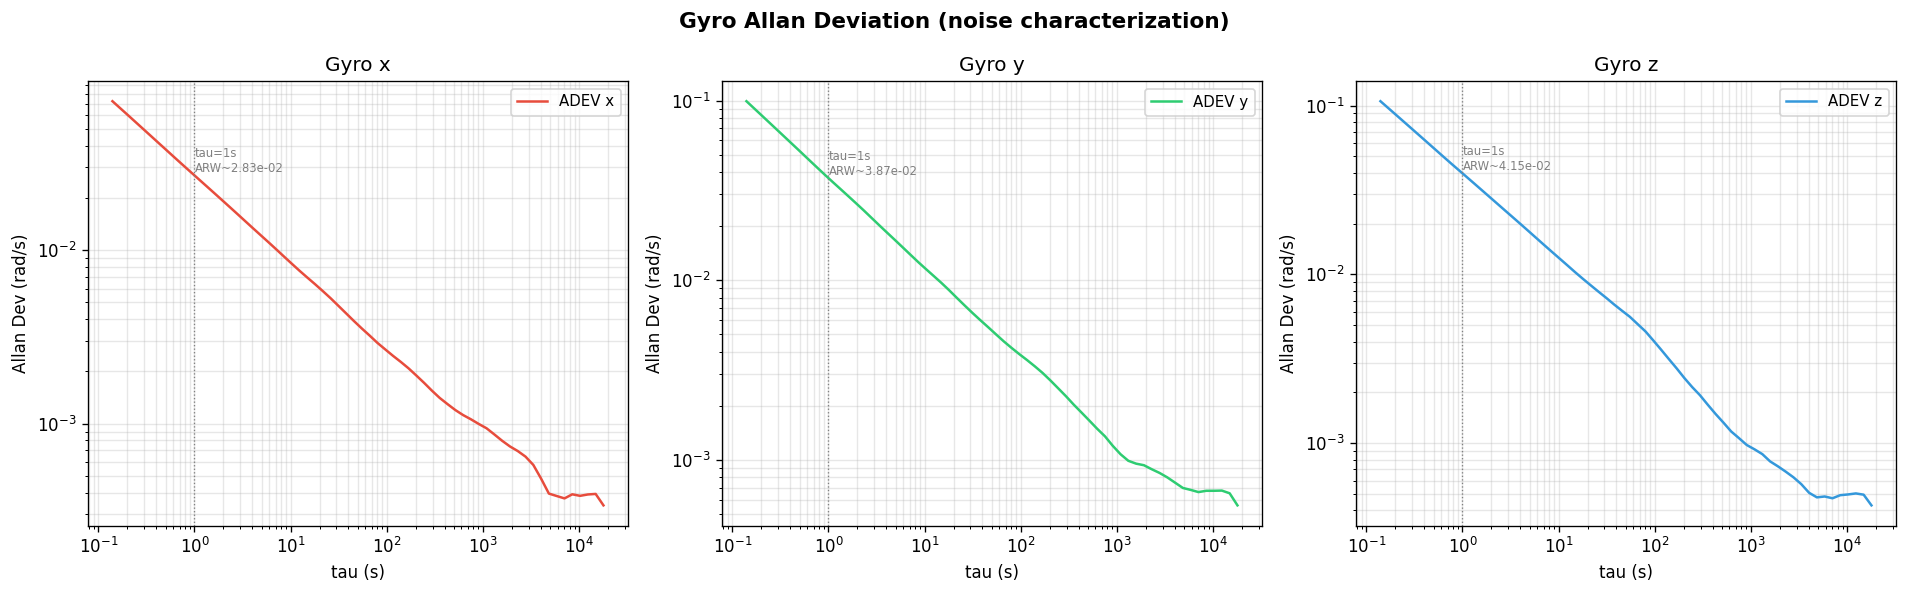


  How to read the Gyro Allan Deviation plot:
  - Slope ~ -0.5 (left)   ->  White noise / Angle Random Walk (ARW)
  - Slope ~  0   (min)    ->  Bias Instability
  - Slope ~ +0.5 (right)  ->  Rate Random Walk / Drift

  Accel Allan Variance...
  Accel sampling rate (from timestamps): 249.99 Hz
    [x] N=794,079  fs_eff=14.71 Hz  decimate=17x  duration=54000 s  tau_max=18000 s
    [y] N=794,079  fs_eff=14.71 Hz  decimate=17x  duration=54000 s  tau_max=18000 s
    [z] N=794,079  fs_eff=14.71 Hz  decimate=17x  duration=54000 s  tau_max=18000 s


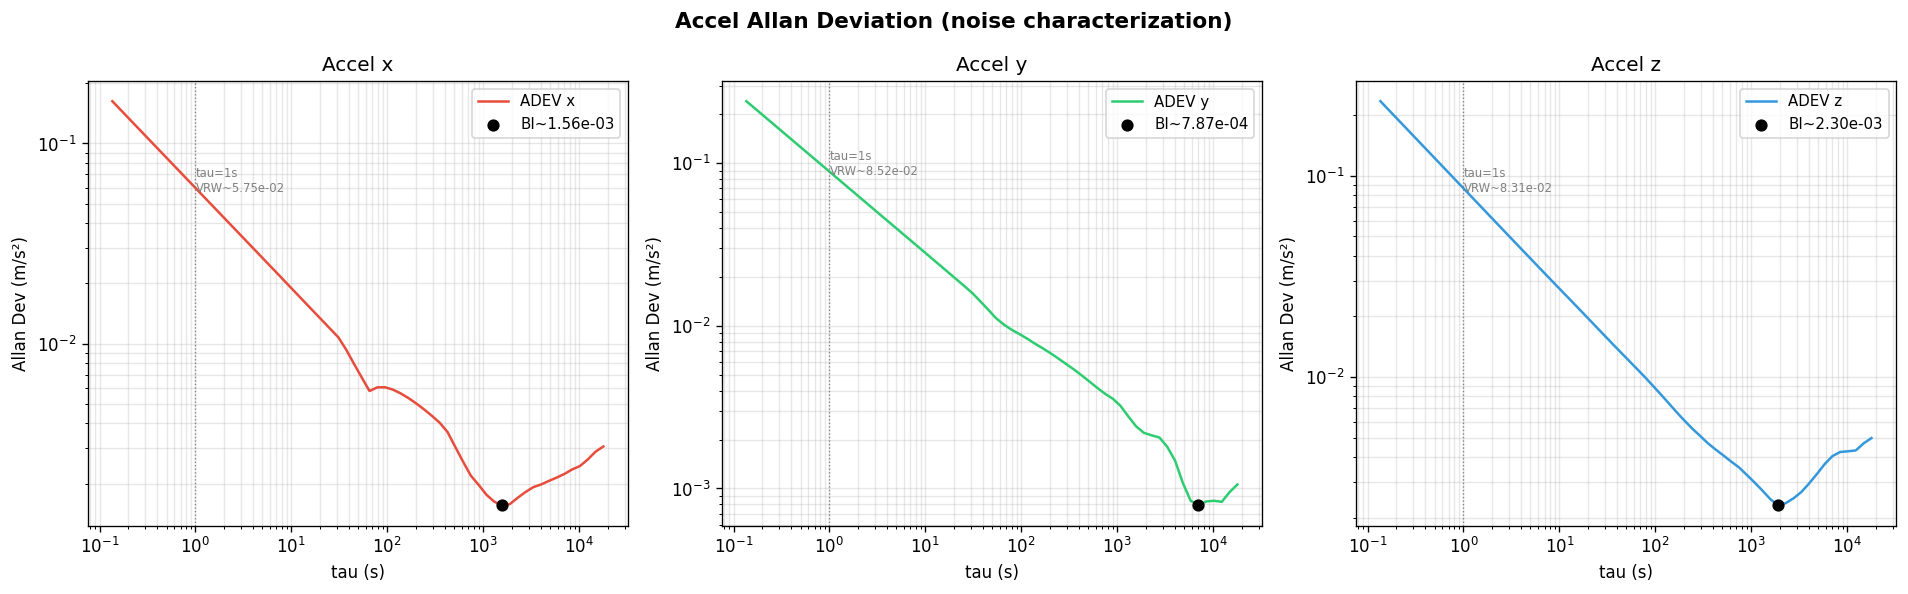


  How to read the Accel Allan Deviation plot:
  - Slope ~ -0.5 (left)   ->  White noise / Velocity Random Walk (VRW)  [m/s²/√Hz]
  - Slope ~  0   (min)    ->  Bias Instability  [m/s²]
  - Slope ~ +0.5 (right)  ->  Accel Rate Random Walk / long-term drift


In [21]:
# ============================================================
# Module 7: Allan Variance (Gyro + Accel noise characterization)
# ============================================================
print("\n[7/8] Allan Variance analysis (Gyro + Accel)...")
print("  (Allan Variance is a noise characterization tool -- no compensation is applied)")

# --- Performance: auto-decimation covers full duration while keeping points ≤ ALLAN_MAX_SAMPLES ---
# Decimation step is computed from total length so tau_max reflects the full recording length.
ALLAN_MAX_SAMPLES = 800_000  # Target upper bound on number of samples after decimation
ALLAN_TAU_POINTS  = 64       # Number of tau values (log-uniform); higher = slower

def prepare_allan_series(series, fs_hz, max_samples):
    """
    Auto-decimate uniformly across the FULL series so that:
      - total number of points <= max_samples  (fast computation)
      - the entire recording duration is preserved (wide tau range)
    Returns (data, effective_fs, decimate_factor).
    """
    x = series.dropna().values.astype(float)
    n = len(x)
    decimate = max(1, int(np.ceil(n / max_samples)))
    x = x[::decimate]
    fs_eff = fs_hz / decimate
    return x, fs_eff, decimate

def build_tau_seconds(n, fs_hz, n_tau):
    """Build available tau values (in seconds) for overlapping Allan calculation; maximum tau is about 1/3 of the total record length."""
    if n < 10 or fs_hz <= 0:
        return None
    T = n / fs_hz
    tau_min = max(2.0 / fs_hz, 1e-6)
    tau_max = min(T / 3.0, T * 0.45)
    if tau_max <= tau_min:
        tau_max = tau_min * 100
    return np.logspace(np.log10(tau_min), np.log10(tau_max), num=n_tau)

def compute_allan(data, fs, taus_sec):
    """
    Compute Overlapping Allan Deviation.
    Returns tau (s) and adev (same unit / sqrt(s)), or (None, None) on failure.
    """
    try:
        t2, ad, ade, adn = allantools.oadev(
            data, rate=fs, data_type='freq', taus=taus_sec)
        return t2, ad
    except Exception as e:
        print(f"    Allan computation failed: {e}")
        return None, None

# Use the estimated gyro sampling rate
gyro_fs = rep_gyro['freq_hz'] if rep_gyro['freq_hz'] else 100.0
print(f"  Gyro sampling rate (from timestamps): {gyro_fs} Hz")

fig, axes_p = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Gyro Allan Deviation (noise characterization)", fontsize=13, fontweight='bold')

allan_results = {}
for i, ax_name in enumerate(['x', 'y', 'z']):
    g, fs_eff, dec = prepare_allan_series(
        df_gyro[ax_name], gyro_fs, ALLAN_MAX_SAMPLES)
    taus_sec = build_tau_seconds(len(g), fs_eff, ALLAN_TAU_POINTS)
    if taus_sec is None:
        print(f"    [{ax_name}] Too few points for Allan.")
        t2, ad = None, None
    else:
        duration_s = len(g) / fs_eff
        print(f"    [{ax_name}] N={len(g):,}  fs_eff={fs_eff:.2f} Hz  "
              f"decimate={dec}x  duration={duration_s:.0f} s  "
              f"tau_max={taus_sec[-1]:.0f} s")
        t2, ad = compute_allan(g, fs_eff, taus_sec)
    if t2 is not None:
        axes_p[i].loglog(t2, ad, color=COLORS[ax_name], lw=1.5, label=f'ADEV {ax_name}')

        # Mark tau = 1 s to read off Angle Random Walk (ARW)
        idx_1s = np.argmin(np.abs(t2 - 1.0))
        arw    = ad[idx_1s] if idx_1s < len(ad) else None
        if arw:
            axes_p[i].axvline(1.0, color='gray', ls=':', lw=0.8)
            axes_p[i].annotate(f'tau=1s\nARW~{arw:.2e}',
                                xy=(1.0, arw), fontsize=7, color='gray')

        axes_p[i].set_xlabel('tau (s)')
        axes_p[i].set_ylabel('Allan Dev (rad/s)')
        axes_p[i].set_title(f'Gyro {ax_name}')
        axes_p[i].legend(fontsize=9)
        axes_p[i].grid(True, which='both', alpha=0.3)
        allan_results[ax_name] = {'tau': t2, 'adev': ad}
    else:
        axes_p[i].set_title(f'Gyro {ax_name} -- computation failed')

plt.tight_layout()
plt.savefig("gyro_allan.png", bbox_inches='tight')
plt.show()

print("\n  How to read the Gyro Allan Deviation plot:")
print("  - Slope ~ -0.5 (left)   ->  White noise / Angle Random Walk (ARW)")
print("  - Slope ~  0   (min)    ->  Bias Instability")
print("  - Slope ~ +0.5 (right)  ->  Rate Random Walk / Drift")

# ── Accel Allan Variance ──────────────────────────────────────
print("\n  Accel Allan Variance...")
accel_fs = rep_accel['freq_hz'] if rep_accel['freq_hz'] else 100.0
print(f"  Accel sampling rate (from timestamps): {accel_fs} Hz")

fig, axes_p = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Accel Allan Deviation (noise characterization)", fontsize=13, fontweight='bold')

accel_allan_results = {}
for i, ax_name in enumerate(['x', 'y', 'z']):
    a, fs_eff, dec = prepare_allan_series(
        df_accel[ax_name], accel_fs, ALLAN_MAX_SAMPLES)
    taus_sec = build_tau_seconds(len(a), fs_eff, ALLAN_TAU_POINTS)
    if taus_sec is None:
        print(f"    [{ax_name}] Too few points for Allan.")
        t2, ad = None, None
    else:
        duration_s = len(a) / fs_eff
        print(f"    [{ax_name}] N={len(a):,}  fs_eff={fs_eff:.2f} Hz  "
              f"decimate={dec}x  duration={duration_s:.0f} s  "
              f"tau_max={taus_sec[-1]:.0f} s")
        t2, ad = compute_allan(a, fs_eff, taus_sec)
    if t2 is not None:
        axes_p[i].loglog(t2, ad, color=COLORS[ax_name], lw=1.5, label=f'ADEV {ax_name}')

        # Mark tau = 1 s to read off Velocity Random Walk (VRW)
        idx_1s = np.argmin(np.abs(t2 - 1.0))
        vrw    = ad[idx_1s] if idx_1s < len(ad) else None
        if vrw:
            axes_p[i].axvline(1.0, color='gray', ls=':', lw=0.8)
            axes_p[i].annotate(f'tau=1s\nVRW~{vrw:.2e}',
                               xy=(1.0, vrw), fontsize=7, color='gray')

        # Mark the minimum (Bias Instability)
        min_idx = np.argmin(ad)
        axes_p[i].scatter(t2[min_idx], ad[min_idx],
                          color='k', s=40, zorder=5, label=f'BI~{ad[min_idx]:.2e}')

        axes_p[i].set_xlabel('tau (s)')
        axes_p[i].set_ylabel('Allan Dev (m/s²)')
        axes_p[i].set_title(f'Accel {ax_name}')
        axes_p[i].legend(fontsize=9)
        axes_p[i].grid(True, which='both', alpha=0.3)
        accel_allan_results[ax_name] = {'tau': t2, 'adev': ad}
    else:
        axes_p[i].set_title(f'Accel {ax_name} -- computation failed')

plt.tight_layout()
plt.savefig("accel_allan.png", bbox_inches='tight')
plt.show()

print("\n  How to read the Accel Allan Deviation plot:")
print("  - Slope ~ -0.5 (left)   ->  White noise / Velocity Random Walk (VRW)  [m/s²/√Hz]")
print("  - Slope ~  0   (min)    ->  Bias Instability  [m/s²]")
print("  - Slope ~ +0.5 (right)  ->  Accel Rate Random Walk / long-term drift")


In [22]:
# ============================================================
# Module 8: Summary Report
# ============================================================
print("\n[8/8] Summary Report")
print("=" * 60)

print("\n+--- GYRO Summary (GT = 0 rad/s) ----------------------------+")
for ax in ['x', 'y', 'z']:
    s           = gyro_stats[ax]
    outlier_pct = outlier_results['Gyro']['masks_z'][ax].sum() / len(df_gyro) * 100
    print(f"  w_{ax}: Bias={s['bias']:+.5f}  Std={s['std']:.5f}  "
          f"RMS={s['rms']:.5f}  Outliers={outlier_pct:.3f}%")
print("  Check: Is Bias significantly non-zero? "
      "Axis Std differences? Allan minimum?")
print("+" + "-"*55 + "+")

print("\n+--- ACCEL Summary (static, ||a|| ~ 9.81 m/s²) --------------+")
for ax in ['x', 'y', 'z']:
    s           = accel_stats[ax]
    outlier_pct = outlier_results['Accel']['masks_z'][ax].sum() / len(df_accel) * 100
    print(f"  a_{ax}: Mean={s['mean']:+.4f}  Std={s['std']:.5f}  Outliers={outlier_pct:.3f}%")
ge = accel_stats['grav_error']
print(f"  ||a|| gravity error: Bias={ge['bias']:+.5f}  Std={ge['std']:.5f}  RMS={ge['rms']:.5f}")
print("  Check: ||a|| deviation from 9.81? Axis alignment error? Noise uniformity?")
print("+" + "-"*55 + "+")

print("\n+--- MAG Summary (stable reference, focus on stability) -----+")
for ax in ['x', 'y', 'z']:
    s           = mag_stats[ax]
    outlier_pct = outlier_results['Mag']['masks_z'][ax].sum() / len(df_mag) * 100
    print(f"  B_{ax}: Mean={s['mean']:+.4f}  Std={s['std']:.4f}  "
          f"CV={s['cv']:.3f}%  Outliers={outlier_pct:.3f}%")
print(f"  ||B||: Mean={mag_stats['magnitude']['mean']:.4f}  "
      f"Std={mag_stats['magnitude']['std']:.4f}")
print("  Check: CV% < 1%? Any linear drift over time?")
print("+" + "-"*55 + "+")

print("\n+--- Outlier Temporal Distribution Summary -------------------+")
for sname in ['Gyro', 'Accel', 'Mag']:
    rates   = outlier_results[sname]['seg_rates']
    max_seg = outlier_results[sname]['seg_labels'][np.argmax(rates)]
    print(f"  {sname}: Peak segment = {max_seg}  ({max(rates):.2f}%)  "
          f"Lowest = {min(rates):.2f}%")
print("+" + "-"*55 + "+")

print("\n✅ All analysis complete. Figures saved to the current directory.")
print("=" * 60)


[8/8] Summary Report

+--- GYRO Summary (GT = 0 rad/s) ----------------------------+
  w_x: Bias=+0.00833  Std=0.11599  RMS=0.11629  Outliers=0.432%
  w_y: Bias=-0.00930  Std=0.15865  RMS=0.15892  Outliers=0.414%
  w_z: Bias=-0.00630  Std=0.14134  RMS=0.14148  Outliers=0.433%
  Check: Is Bias significantly non-zero? Axis Std differences? Allan minimum?
+-------------------------------------------------------+

+--- ACCEL Summary (static, ||a|| ~ 9.81 m/s²) --------------+
  a_x: Mean=+0.3595  Std=0.21036  Outliers=0.001%
  a_y: Mean=-0.2852  Std=0.35211  Outliers=0.002%
  a_z: Mean=+9.7535  Std=0.42705  Outliers=0.003%
  ||a|| gravity error: Bias=-0.04237  Std=0.53459  RMS=0.53626
  Check: ||a|| deviation from 9.81? Axis alignment error? Noise uniformity?
+-------------------------------------------------------+

+--- MAG Summary (stable reference, focus on stability) -----+
  B_x: Mean=+7.1362  Std=3.1462  CV=44.088%  Outliers=0.001%
  B_y: Mean=-9.1238  Std=4.7554  CV=52.121%  Outli